# Simulating on a Par 3 - hole 9 MM

In [42]:
import pandas as pd
import numpy as np
from shapely import wkt
from shapely.geometry import Point
import matplotlib.pyplot as plt

In [43]:
lpga_clubs = pd.read_csv("/Users/federicadomecq/Documents/golfModeL47-1/PART 1/Trackman Fake Data/simulated_lpga_shot_data.csv")
hole_9 = pd.read_csv("/Users/federicadomecq/Documents/golfModeL47-1/PART 1/Map Digitisation/Mountain Meadows/MountainMeadows_Separated/hole_9/hole_9_data.csv")

### Selecting Teebox

In [ ]:
# to get the centre of shapes
def get_centroid(row):
    shape = wkt.loads(row["WKT"])
    return shape.centroid.coords[0] # returns the x,y coords

# finding furthest teebox
teeboxes = hole_9[hole_9["lie"].str.contains("tee", case = False)]
green = hole_9[hole_9["lie"] == "green"].iloc[0]
green_shape = wkt.loads(green["WKT"])
green_centre = get_centroid(green)
# getting different teeboxes centre
teeboxes["centroid"] = teeboxes.apply(get_centroid, axis=1) #axis 1 passes a row instead of column

# distances to green
teeboxes["dist_to_green"] = teeboxes["centroid"].apply(
    # np.array(pt) - np.array(green_centre) -> subtracts the two 2d points, and linalg compute the euclidean distance
    lambda pt: np.linalg.norm(np.array(pt) - np.array(green_centre))
)

longest_teebox = teeboxes.loc[teeboxes["dist_to_green"].imax()]
tee_point = longest_teebox["centroid"]


# --- from simulating putting, to define random hole location
def sample_point_on_green(green_shape):
    # get the bounds of the green shape
    minx, miny, maxx, maxy = green_shape.bounds

    while True:
        # randomly generate random coordinate
        x_ball = np.random.uniform(minx, maxx)
        y_ball = np.random.uniform(miny, maxy)
        # check whether point is on green
        if green_shape.contains(Point(x_ball, y_ball)):
            return (x_ball, y_ball)
        
hole = sample_point_on_green(green_shape)

hole = (5, 174)

/var/folders/vr/34gvhdpn06z_plwsw13j8w4c0000gn/T/ipykernel_98839/3202513976.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  teeboxes["centroid"] = teeboxes.apply(get_centroid, axis=1) #axis 1 passes a row instead of column
/var/folders/vr/34gvhdpn06z_plwsw13j8w4c0000gn/T/ipykernel_98839/3202513976.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  teeboxes["dist_to_green"] = teeboxes["centroid"].apply(


### Printing Pin Position and Tee Box

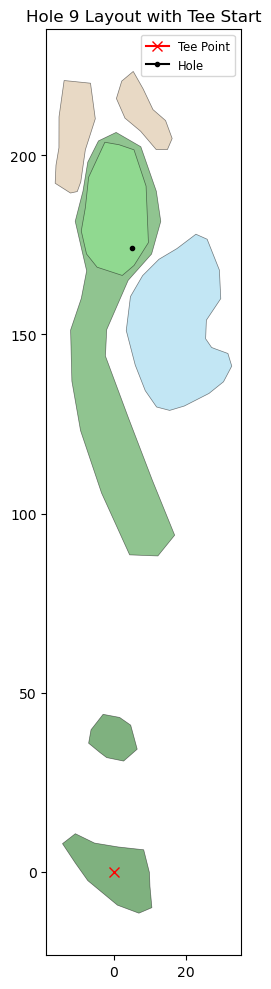

In [50]:
# colors by lie type
lie_colors = {
    "bunker": "tan",
    "fairway": "forestgreen",
    "green": "lightgreen",
    "OB": "lightcoral",
    "rough": "mediumseagreen",
    "tee": "darkgreen",
    "water_hazard": "skyblue"
}

fig, ax = plt.subplots(figsize=(10, 10))

# fill each shape with the appropriate colour
for _, row in hole_9.iterrows():
    geom = wkt.loads(row["WKT"])
    color = lie_colors.get(row["lie"], "lightgrey")

    if geom.geom_type == "Polygon":
        x, y = geom.exterior.xy
        ax.fill(x, y, alpha=0.5, fc=color, edgecolor="black", linewidth=0.5)
    elif geom.geom_type == "MultiPolygon":
        for poly in geom.geoms:
            x, y = poly.exterior.xy
            ax.fill(x, y, alpha=0.5, fc=color, edgecolor="black", linewidth=0.5)

# mark tee and hole
ax.plot(tee_point[0], tee_point[1], marker='x', color='red', markersize=7, label="Tee Point")
ax.plot(hole[0], hole[1], marker='o', color='black', markersize=3, label="Hole")

ax.set_aspect("equal")
ax.set_title("Hole 9 Layout with Tee Start")
ax.legend(loc='upper right', fontsize="small")
plt.tight_layout()
plt.show()


## Simulating Shots
Rotating and translating LPGA shots

### Rotation Matrices
If have a coordinate with form relative to the aimpoint:
$$(x,y)$$
To rotate it $\theta$ degrees anticlockwise (i.e. left), you multiply with:
$$\text{Rot}_{\theta} = \begin{bmatrix} \cos(\theta) &- \sin(\theta)\\
\sin(\theta) & \cos(\theta)\end{bmatrix}$$

In [ ]:
def rotation_translator(x_side,y_carry, angle, starting_point, target):

    # base angle from starting_point to target
    line_to_target = np.array(target) - np.array(starting_point)
    base_angle = np.arctan2(line_to_target[1], line_to_target[0])

    # aiming offset
    theta = -np.radians(angle) + base_angle
    # rotation matrix
    rot_matrix = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta), np.cos(theta)]
    ])

    # Rotate shot vector
    original_vec = np.array([x_side, -y_carry])
    rotated_vec = rot_matrix @ original_vec

    # rotating the *rotated vector* into the global frame using base_angle
    global_rot = np.array([
        [np.cos(base_angle), -np.sin(base_angle)],
        [np.sin(base_angle),  np.cos(base_angle)]
    ])
    final_vec = global_rot @ rotated_vec

    # Add tee location
    return tuple(final_vec + np.array(starting_point))

## Offset Angle in Yards -> SOHCAHTOA FOR INTERPRETABILITY
Want to aim at a point:
- distance d (straight line)
- x lateral offset

So via sohcahtoa

$$\theta = \arctan(\frac{x}{d})$$

In [ ]:
def yard_offset_to_angle(yards_offset, starting_point, target):
    """
    Convert lateral aiming offset (in yards) into degrees offset from the tee line to the hole.
    Positive = right, Negative = left.
    """
    starting_point = np.array(starting_point)
    target = np.array(target)
    # straight_line distance to hole
    dis_target = np.linalg.norm(target - starting_point)

    # using sohcahtoa
    angle_rad = np.arctan(yards_offset / dis_target)
    return np.degrees(angle_rad)

def angle_offset_to_yard(angle_offset, starting_point, target):
    """
    Convert lateral aiming offset (in yards) into degrees offset from the tee line to the hole.
    Positive = right, Negative = left.
    """
    starting_point = np.array(starting_point)
    target = np.array(target)
    # straight_line distance to hole
    dis_target = np.linalg.norm(target - starting_point)

    # using sohcahtoa
    angle_rad = np.radians(angle_offset)
    offset = np.tan(angle_rad) * dis_target
    return offset

## Interactive Plot to Visualise Different aimpoints

In [ ]:
from ipywidgets import interact, Dropdown, IntSlider

# base distance (to target)
total_distance = np.linalg.norm(np.array(hole) - np.array(tee_point))

# Just for the Drop Down menu
club_order = [
    "Driver", "3-wood", "5-wood", "Hybrid",
    "4 Iron", "5 Iron", "6 Iron", "7 Iron", "8 Iron", "9 Iron",
    "PW", "50 deg", "54 deg", "60 deg"
]
sorted_clubs = [club for club in club_order if club in lpga_clubs["Club"].unique()]

# Interactive widget with dropdown for irons
@interact(
    club=Dropdown(options=sorted_clubs, value="5 Iron", description="Club:"),
    aim_yards=IntSlider(min=-20, max=20, step=1, value=0, description="Aim (yds):")
)

def plot_rotated_shots(club, aim_yards):
    fig, ax = plt.subplots(figsize=(10, 10))

    # Filter club data
    club_df = lpga_clubs[lpga_clubs["Club"] == club].copy()

    # Convert aim offset in yards to angle in degrees
    angle_rad = np.arctan(aim_yards / total_distance)
    angle_deg = np.degrees(angle_rad)

    # Draw hole
    for _, row in hole_9.iterrows():
        geom = wkt.loads(row["WKT"])
        color = lie_colors.get(row["lie"], "lightgrey")
        if geom.geom_type == "Polygon":
            x, y = geom.exterior.xy
            ax.fill(x, y, fc=color, alpha=0.4)
        elif geom.geom_type == "MultiPolygon":
            for poly in geom.geoms:
                x, y = poly.exterior.xy
                ax.fill(x, y, fc=color, alpha=0.4)

    # Plot rotated shots
    for _, row in club_df.iterrows():
        x, y = rotation_translator(row["Side"], row["Carry"], angle_deg, tee_point, hole)
        ax.plot(x, y, marker='.', color='blue', alpha=0.6)

    # Tee & hole
    ax.plot(tee_point[0], tee_point[1], marker='x', color='red', markersize=8, label='Tee')
    ax.plot(hole[0], hole[1], marker='o', color='black', markersize=5, label='Hole')

    # --- Plot Aim Line showing the rotated centerline of shot dispersion ---
    aim_direction = np.array(hole) - np.array(tee_point)
    aim_direction_unit = aim_direction / np.linalg.norm(aim_direction)

    # Rotation matrix to rotate the aim line by the aiming angle (clockwise = positive)
    theta = -angle_rad  # negative so positive input rotates clockwise
    rot_matrix = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])

    rotated_aim_direction = rot_matrix @ aim_direction_unit

    # Extend from tee point outward by total_distance
    aim_endpoint = np.array(tee_point) + rotated_aim_direction * total_distance

    # Plot the rotated aim line
    ax.plot(
        [tee_point[0], aim_endpoint[0]],
        [tee_point[1], aim_endpoint[1]],
        linestyle="--",
        color="red",
        label="Aim Point"
    )
    
        # Grid overlay every 5 yards
    ax.set_xticks(np.arange(-40, 40, 10), minor=False)
    ax.set_yticks(np.arange(-50, 251, 10), minor=False)

    ax.grid(which='major', color='gray', linestyle=':', linewidth=0.5, alpha=0.3)
    ax.set_title(f"{club} | Aim {aim_yards} yd, {round(angle_deg, 2)}°")
    ax.set_aspect("equal")
    ax.legend()
    plt.tight_layout()
    plt.show()

# Simulating, the mathematical way ;)
## Fit Bivariate Gaussian to LPGA Shot Data
Define:
- $X$ -> Side (yards left/right)
- $Y$ -> Carry (forward)

From LPGA shots with a given $\mathcal{c}$:
Compute, gaussian distribution:
$$\mu_{\mathcal{c}} = \begin{bmatrix} \mu_X \\ \mu_Y \end{bmatrix}, \Sigma_{\mathcal{c}} = \begin{bmatrix} \sigma^2_{X} & \rho\sigma_X\sigma_Y \\
\rho\sigma_X\sigma_Y & \sigma^2_{Y}\end{bmatrix}$$

## Sampling Shots from Gaussian
Simulate $N$ shots
$$\vec{s} \sim \mathcal{N}(\mu_\mathcal c, \Sigma_ \mathcal c)$$

## Rotate and Translate to Hole setting

Let:

* $\vec{v} = \text{unit vector from tee to pin}$
* $\theta = \arctan(\text{aim}_\text{offset} / \text{distance to pin})$

Then:

* Want to rotate each shot $\vec{s}_i$ by angle $\theta$ (clockwise = +)
* Translate from tee location:

$$
\vec{p}_i = \text{Tee} + R(\theta) \cdot \vec{s}_i
$$

## Evaluate Strokes-to-Hole for Each Landing Point

Define function:

$$
\text{ExpectedStrokes}(\vec{p}_i) =
\begin{cases}
\text{GPR-putting} & \text{if } \vec{p}_i \in \text{green} \\
\text{Broadie interpolation} & \text{if } \vec{p}_i \in \text{fairway, rough, bunker} \\
\text{Drop + Broadie} & \text{if } \vec{p}_i \in \text{water}
\end{cases}
$$

## Summarise Results

From values $\{ \text{ES}_i \}_{i=1}^N$, compute:

* $\mathbb{E}[\text{Strokes}] = \frac{1}{N} \sum_i \text{ES}_i$
* $\text{95\% CI} = \text{quantile range of } \{ \text{ES}_i \}$



# Bivariate LPGA distribution
Computing and Plotting for Visual Purpose

/var/folders/vr/34gvhdpn06z_plwsw13j8w4c0000gn/T/ipykernel_98839/1113651003.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', len(clubs))


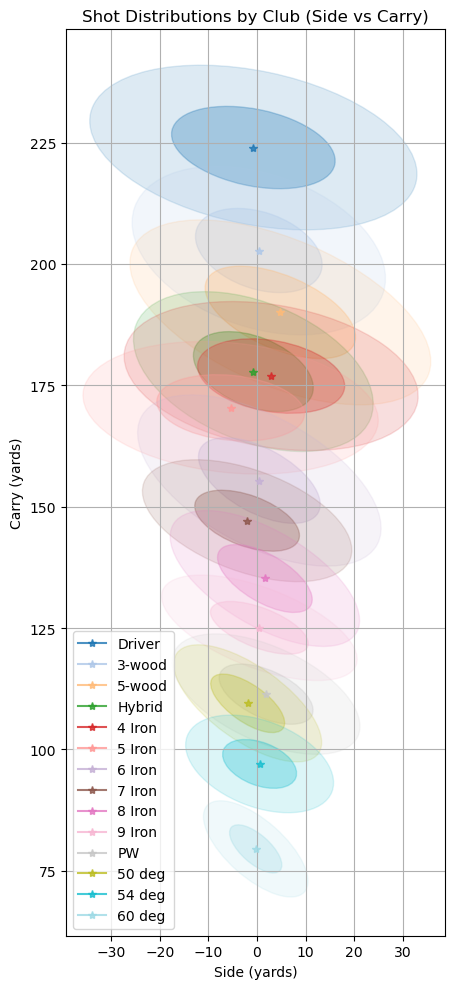

In [ ]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.patches import Ellipse

# Computing and storing values
club_distributions = {}

# Computing
for club in lpga_clubs["Club"].unique():
    club_df = lpga_clubs[lpga_clubs["Club"] == club]

    X = club_df[["Side", "Carry"]].to_numpy()
    mu = np.mean(X, axis = 0)
    cov = np.cov(X, rowvar= False)

    club_distributions[club] = {"mean":mu, "cov":cov}

fig, ax = plt.subplots(figsize=(10, 10))

#defining colourmap
clubs = list(club_distributions.keys())
norm = mcolors.Normalize(vmin=0, vmax=len(clubs) - 1)
cmap = cm.get_cmap('tab20', len(clubs))

for i, club in enumerate(clubs):
    mu = club_distributions[club]["mean"]
    cov = club_distributions[club]["cov"]

    # Plot mean
    ax.plot(mu[0], mu[1], marker='*', color=cmap(i), label=club, alpha=0.8)

    # GOOGLE SECTION 1

    # Perform eigen decomposition of the covariance matrix
        # vals = eigenvalues (variance along each principal direction)
        # vecs = eigenvectors (directions of the principal axes)
    vals, vecs = np.linalg.eigh(cov)

    # Sort eigenvalues and corresponding eigenvectors in descending order
    order = vals.argsort()[::-1] 
    vals, vecs = vals[order], vecs[:, order] 

    # Compute the rotation angle of the ellipse in degrees
    #  take the arctangent of the first eigenvector's y and x components
    # This gives us the angle the ellipse's major axis makes with the x-axis
    theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))


    # Plot 1sd ellipse
    width_1, height_1 = 2 * np.sqrt(vals)
    ell_1 = Ellipse(xy=mu, width=width_1, height=height_1, angle=theta,
                    edgecolor=cmap(i), facecolor=cmap(i), alpha=0.3, lw=1)
    ax.add_patch(ell_1)

    # Plot 2sd ellipse
    width_2, height_2 = 2 * 2 * np.sqrt(vals)
    ell_2 = Ellipse(xy=mu, width=width_2, height=height_2, angle=theta,
                    edgecolor=cmap(i), facecolor=cmap(i), alpha=0.15, lw=1)
    ax.add_patch(ell_2)

# Final touches
ax.set_title("Shot Distributions by Club (Side vs Carry)")
ax.set_xlabel("Side (yards)")
ax.set_ylabel("Carry (yards)")
ax.legend()
ax.set_aspect('equal')
plt.grid(True)
plt.tight_layout()
plt.show()


## Simulating Shots

In [99]:
def get_club_distribution(club):
    return club_distributions[club]["mean"],  club_distributions[club]["cov"]

def simulate_shots(club, aim_point, n_samples, starting_point, target):
    mu, cov = get_club_distribution(club)

    # sampling shots
    shots = np.random.multivariate_normal(mu, cov, size= n_samples)

    # Convert aimpoint to angle
    total_distance = np.linalg.norm(np.array(target) - np.array(starting_point))
    angle_rad = np.arctan(aim_point / total_distance)
    angle_deg = np.degrees(angle_rad)

    # translate and rotate each shot
    rotated_shots = []
    for shot in shots:
        x, y = rotation_translator(shot[0], shot[1], angle_deg, tee_point, hole)
        rotated_shots.append((x, y))

    return np.array(rotated_shots)

### Shot Evaluation:

For each simulated shot landing point $(x, y)$:

####  If the point is on the green:

* GPR and Modifier Used to Evaluate

#### If point in fairway / rough / bunker:

* Use interpolation from Broadie’s expected strokes tables
* * for now

#### If it lands in water:

* Trace the line from tee to the ball
* Find first intersection with the water polygon
* Compute drop point there and re-evaluate expected strokes from drop point